In [2]:
# ================================================================
# CELL 1 — Configuration
# ================================================================

# -----------------------------
# Hugging Face Model Names
# -----------------------------

# Base embedding model
BASE_MODEL = "Qwen/Qwen3-Embedding-0.6B"

# Fine-tuned model (CHANGE ONLY IF YOUR REPO NAME IS DIFFERENT)
FT_MODEL = "boq-retrieval-team/boq-retrieval-team"

# -----------------------------
# Hardware
# -----------------------------

DEVICE = "cuda"      # Colab T4/V100/A100
USE_FP16 = True      # Faster GPU inference

# -----------------------------
# Embedding
# -----------------------------

BATCH_SIZE = 32      # Increase to 512 if GPU memory allows
NORMALIZE = True

# -----------------------------
# Retrieval
# -----------------------------

TOP_K = [1, 3, 5, 10]

# -----------------------------
# Random Seed
# -----------------------------

SEED = 42

# -----------------------------
# Output Directory
# -----------------------------

OUTPUT_DIR = "benchmark_output"

# -----------------------------
# Embedding Cache
# -----------------------------

CACHE_DIR = "embedding_cache"

# -----------------------------
# Visualization
# -----------------------------

FIG_DPI = 200

print("=" * 60)
print("Configuration Loaded")
print("=" * 60)

print(f"Base Model      : {BASE_MODEL}")
print(f"Fine-tuned      : {FT_MODEL}")
print(f"Device          : {DEVICE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Top-K           : {TOP_K}")
print("=" * 60)

Configuration Loaded
Base Model      : Qwen/Qwen3-Embedding-0.6B
Fine-tuned      : boq-retrieval-team/boq-retrieval-team
Device          : cuda
Batch Size      : 32
Top-K           : [1, 3, 5, 10]


In [2]:
# ================================================================
# CELL 2 — Install Dependencies (Qwen3 Compatible)
# ================================================================

!pip install -U -q \
"transformers>=4.53.0" \
"sentence-transformers>=5.0.0" \
"accelerate>=1.8.0" \
"huggingface_hub>=0.34.0" \
"datasets>=3.0.0" \
pdfplumber \
PyMuPDF \
faiss-cpu \
scikit-learn \
matplotlib \
plotly \
umap-learn \
openpyxl \
reportlab \
tqdm

print("="*60)
print("✅ Dependencies installed successfully")
print("="*60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9

In [3]:
import torch
import transformers
import sentence_transformers

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

print("Transformers:", transformers.__version__)
print("SentenceTransformers:", sentence_transformers.__version__)

Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Transformers: 5.12.1
SentenceTransformers: 5.6.0


In [4]:
# ================================================================
# CELL 3 — Imports & Environment Verification
# ================================================================

import os
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import faiss
import fitz  # PyMuPDF
import pdfplumber

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from tqdm.auto import tqdm
from datasets import Dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics import ndcg_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import umap.umap_ as umap

warnings.filterwarnings("ignore")

# ------------------------------------------------
# Random Seed
# ------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------
# Device Detection
# ------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("Environment Verification")
print("=" * 60)

print(f"Python               : {os.sys.version.split()[0]}")
print(f"Torch                : {torch.__version__}")
print(f"CUDA Available       : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU                  : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version         : {torch.version.cuda}")
else:
    print("GPU                  : Not Available (Running on CPU)")

print(f"SentenceTransformers : {SentenceTransformer.__module__.split('.')[0]}")
print(f"FAISS                : {faiss.__version__}")
print(f"PyMuPDF              : {fitz.version[0]}")
print(f"pdfplumber           : {pdfplumber.__version__}")

# ------------------------------------------------
# Create Required Directories
# ------------------------------------------------

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

Path(f"{OUTPUT_DIR}/plots").mkdir(parents=True, exist_ok=True)
Path(f"{OUTPUT_DIR}/reports").mkdir(parents=True, exist_ok=True)
Path(f"{OUTPUT_DIR}/tables").mkdir(parents=True, exist_ok=True)
Path(f"{CACHE_DIR}/embeddings").mkdir(parents=True, exist_ok=True)
Path(f"{CACHE_DIR}/faiss").mkdir(parents=True, exist_ok=True)

print("\nDirectories Created:")
print(f"  📁 {OUTPUT_DIR}")
print(f"  📁 {CACHE_DIR}")

# ------------------------------------------------
# GPU Optimization
# ------------------------------------------------

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

    print("\nGPU optimizations enabled.")

print("=" * 60)
print("✅ Cell 3 completed successfully.")
print("=" * 60)

Environment Verification
Python               : 3.12.13
Torch                : 2.11.0+cu128
CUDA Available       : True
GPU                  : Tesla T4
CUDA Version         : 12.8
SentenceTransformers : sentence_transformers
FAISS                : 1.14.3
PyMuPDF              : 1.28.0
pdfplumber           : 0.11.10

Directories Created:
  📁 benchmark_output
  📁 embedding_cache

GPU optimizations enabled.
✅ Cell 3 completed successfully.


In [5]:
from huggingface_hub import login, HfApi

# ------------------------------------------------
# Login to Hugging Face
# ------------------------------------------------

try:
    login(skip_if_logged_in=True)
except Exception as e:
    print(f"Login skipped: {e}")

# ------------------------------------------------
# Repository Validation
# ------------------------------------------------

BASE_MODEL = globals().get("BASE_MODEL", "BAAI/bge-small-en-v1.5")
FT_MODEL = globals().get("FT_MODEL", "boq-retrieval-team/boq-retrieval-team")

api = HfApi()

print("=" * 60)
print("Validating Hugging Face Repositories")
print("=" * 60)

# Base model
try:
    api.model_info(BASE_MODEL)
    print(f"✅ Base Model Found      : {BASE_MODEL}")
except Exception as e:
    raise Exception(f"Base model not accessible:\n{e}")

# Fine-tuned model
try:
    api.model_info(FT_MODEL)
    print(f"✅ Fine-Tuned Model Found: {FT_MODEL}")
except Exception as e:
    raise Exception(
        f"Fine-tuned model not accessible.\n"
        f"Check repository name or permissions.\n\n{e}"
    )

print("=" * 60)
print("✅ Hugging Face setup completed successfully.")
print("=" * 60)

Validating Hugging Face Repositories
✅ Base Model Found      : Qwen/Qwen3-Embedding-0.6B
✅ Fine-Tuned Model Found: boq-retrieval-team/boq-retrieval-team
✅ Hugging Face setup completed successfully.


In [58]:
# ================================================================
# CELL 5 — Upload BOQ PDFs
# ================================================================

from google.colab import files
from pathlib import Path
import shutil
import os

# ------------------------------------------------
# Create PDF Directory
# ------------------------------------------------

PDF_DIR = Path("boq_pdfs")
PDF_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Upload BOQ PDF Files")
print("=" * 60)
print("Select one or more BOQ PDFs.")
print()

# ------------------------------------------------
# Upload Files
# ------------------------------------------------

uploaded = files.upload()

if len(uploaded) == 0:
    raise Exception("No PDF files uploaded.")

# ------------------------------------------------
# Save Files
# ------------------------------------------------

pdf_files = []

for filename in uploaded.keys():

    if not filename.lower().endswith(".pdf"):
        print(f"Skipping non-PDF file: {filename}")
        continue

    destination = PDF_DIR / filename

    shutil.move(filename, destination)

    pdf_files.append(destination)

# ------------------------------------------------
# Summary
# ------------------------------------------------

print("\n" + "=" * 60)
print(f"Successfully uploaded {len(pdf_files)} PDF(s)")
print("=" * 60)

for i, pdf in enumerate(pdf_files, start=1):
    size_mb = os.path.getsize(pdf) / (1024 * 1024)
    print(f"{i}. {pdf.name} ({size_mb:.2f} MB)")

print("=" * 60)

Upload BOQ PDF Files
Select one or more BOQ PDFs.



Saving BOQ_0450_Shopping_Mall_&_Retail_Center.pdf to BOQ_0450_Shopping_Mall_&_Retail_Center.pdf
Saving BOQ_0451_Sewage_Treatment_Facility.pdf to BOQ_0451_Sewage_Treatment_Facility.pdf
Saving BOQ_0451_Solar_Farm_Balance_of_Plant.pdf to BOQ_0451_Solar_Farm_Balance_of_Plant.pdf
Saving BOQ_0452_Airport_Terminal_Expansion.pdf to BOQ_0452_Airport_Terminal_Expansion.pdf
Saving BOQ_0452_Commercial_Office_Complex.pdf to BOQ_0452_Commercial_Office_Complex.pdf
Saving BOQ_0453_Commercial_Office_Complex.pdf to BOQ_0453_Commercial_Office_Complex.pdf
Saving BOQ_0453_Luxury_Hotel_and_Resort.pdf to BOQ_0453_Luxury_Hotel_and_Resort.pdf
Saving BOQ_0454_Luxury_Hotel_and_Resort.pdf to BOQ_0454_Luxury_Hotel_and_Resort.pdf
Saving BOQ_0454_Power_Substation_Construction.pdf to BOQ_0454_Power_Substation_Construction.pdf
Saving BOQ_0455_IT_Park_and_Data_Campus.pdf to BOQ_0455_IT_Park_and_Data_Campus.pdf
Saving BOQ_0455_Power_Substation_Construction.pdf to BOQ_0455_Power_Substation_Construction.pdf
Saving BOQ_045

In [59]:
# ================================================================
# CELL 6 — Extract BOQ Tables
# ================================================================

import pdfplumber
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

print("=" * 60)
print("Extracting BOQ Tables")
print("=" * 60)

all_rows = []

# ------------------------------------------------
# Helper Function
# ------------------------------------------------

def clean_cell(cell):
    if cell is None:
        return ""
    return " ".join(str(cell).replace("\n", " ").split()).strip()

# ------------------------------------------------
# Process Every PDF
# ------------------------------------------------

for pdf_path in tqdm(pdf_files):

    with pdfplumber.open(pdf_path) as pdf:

        for page_number, page in enumerate(pdf.pages, start=1):

            try:
                tables = page.extract_tables()

            except Exception:
                tables = []

            # ----------------------------------------
            # Process Tables
            # ----------------------------------------

            if tables:

                for table_id, table in enumerate(tables):

                    if table is None or len(table) == 0:
                        continue

                    for row_id, row in enumerate(table):

                        if row is None:
                            continue

                        cleaned = [clean_cell(c) for c in row]

                        if all(c == "" for c in cleaned):
                            continue

                        all_rows.append({

                            "pdf_name": pdf_path.name,

                            "page": page_number,

                            "table": table_id + 1,

                            "row": row_id + 1,

                            "cells": cleaned

                        })

            # ----------------------------------------
            # Fallback (No Tables)
            # ----------------------------------------

            else:

                text = page.extract_text()

                if text:

                    for line_id, line in enumerate(text.split("\n")):

                        line = clean_cell(line)

                        if len(line) < 5:
                            continue

                        all_rows.append({

                            "pdf_name": pdf_path.name,

                            "page": page_number,

                            "table": 0,

                            "row": line_id + 1,

                            "cells": [line]

                        })

# ------------------------------------------------
# Create DataFrame
# ------------------------------------------------

raw_df = pd.DataFrame(all_rows)

print("\nExtraction Complete")
print(f"Documents Extracted : {len(raw_df):,}")
print(f"PDFs Processed      : {len(pdf_files)}")

display(raw_df.head(10))

Extracting BOQ Tables


  0%|          | 0/142 [00:00<?, ?it/s]


Extraction Complete
Documents Extracted : 29,727
PDFs Processed      : 142


,pdf_name,page,table,row,cells
0,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,1,"[S.No, Description, Unit, Quantity, Rate, Amount]"
1,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,2,"[1, Metal roofing sheet, complete in all respe..."
2,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,3,"[2, Green roof system, nos, 2,418.34, 5,634.67..."
3,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,4,"[3, Valley gutter - 0.5mm thick, as per drawin..."
4,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,5,"[4, Roof insulation - double skin, rmt, 2,730...."
5,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,6,"[5, Roof truss installation, sqm, 228.91, 3,50..."
6,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,7,"[6, Gutter installation, at second floor, sqm,..."
7,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,8,"[7, Flashing work - 0.5mm thick, as directed b..."
8,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,9,"[8, Roof ventilator - factory curved, sqm, 4,3..."
9,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,10,"[9, Waterproof membrane, in common area, nos, ..."


In [60]:
# ================================================================
# CELL 7 — Clean Tables & Build Retrieval Corpus
# ================================================================

import re
import pandas as pd

print("=" * 60)
print("Building Retrieval Corpus")
print("=" * 60)

HEADER_KEYWORDS = {
    "item", "description", "desc", "unit", "qty",
    "quantity", "rate", "amount", "total", "sr",
    "s.no", "no", "remarks"
}


def normalize(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def is_header_row(cells):
    joined = " ".join(c.lower() for c in cells)
    hits = sum(k in joined for k in HEADER_KEYWORDS)
    return hits >= 2


documents = []

for idx, row in raw_df.iterrows():

    cells = [normalize(c) for c in row["cells"]]

    # Remove empty cells
    cells = [c for c in cells if c != ""]

    if len(cells) == 0:
        continue

    # Skip table headers
    if is_header_row(cells):
        continue

    # ------------------------------------------------
    # Description
    # ------------------------------------------------

    if len(cells) >= 2:
        description = cells[1]
    else:
        description = cells[0]

    description = normalize(description)

    if len(description) < 5:
        continue

    # ------------------------------------------------
    # Metadata
    # ------------------------------------------------

    unit = cells[2] if len(cells) > 2 else ""
    qty = cells[3] if len(cells) > 3 else ""
    rate = cells[4] if len(cells) > 4 else ""
    amount = cells[5] if len(cells) > 5 else ""

    documents.append({

        "doc_id": f"DOC_{len(documents):06d}",

        "text": description,

        "pdf_name": row["pdf_name"],

        "page": row["page"],

        "table": row["table"],

        "row": row["row"],

        "unit": unit,

        "qty": qty,

        "rate": rate,

        "amount": amount

    })

# ------------------------------------------------
# DataFrame
# ------------------------------------------------

corpus_df = pd.DataFrame(documents)

print(f"Total Retrieval Documents : {len(corpus_df):,}")

display(corpus_df.head(10))

# ------------------------------------------------
# Save
# ------------------------------------------------

corpus_path = Path(OUTPUT_DIR) / "tables" / "retrieval_corpus.csv"

corpus_df.to_csv(corpus_path, index=False)

print()
print(f"Saved corpus to:\n{corpus_path}")

print("=" * 60)
print("✅ Retrieval corpus ready.")
print("=" * 60)

Building Retrieval Corpus
Total Retrieval Documents : 26,228


,doc_id,text,pdf_name,page,table,row,unit,qty,rate,amount
0,DOC_000000,"Metal roofing sheet, complete in all respect",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,2,rmt,"3,137.85","6,126.55","19,224,194.92"
1,DOC_000001,Green roof system,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,3,nos,"2,418.34","5,634.67","13,626,547.85"
2,DOC_000002,"Valley gutter - 0.5mm thick, as per drawing",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,4,rmt,"3,542.01","8,254.36","29,237,025.66"
3,DOC_000003,Roof insulation - double skin,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,5,rmt,"2,730.65","3,385.42","9,244,397.12"
4,DOC_000004,Roof truss installation,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,6,sqm,228.91,"3,506.46","802,663.76"
5,DOC_000005,"Gutter installation, at second floor",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,7,sqm,"1,390.93","1,306.98","1,817,917.69"
6,DOC_000006,"Flashing work - 0.5mm thick, as directed by en...",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,8,nos,"3,148.44","4,361.12","13,730,724.65"
7,DOC_000007,Roof ventilator - factory curved,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,9,sqm,"4,359.98","4,610.23","20,100,510.60"
8,DOC_000008,"Waterproof membrane, in common area",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,10,nos,"2,742.04","6,631.61","18,184,139.88"
9,DOC_000009,Skylight installation,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1,1,11,rmt,"4,575.33","8,344.64","38,179,481.73"



Saved corpus to:
benchmark_output/tables/retrieval_corpus.csv
✅ Retrieval corpus ready.


In [61]:
# ================================================================
# CELL 8 — Generate Evaluation Queries (One Query Per Document)
# ================================================================

import random
import pandas as pd

print("="*70)
print("Generating Evaluation Queries")
print("="*70)

random.seed(SEED)

QUERY_TEMPLATES = [
    "Find BOQ item for {}",
    "Locate {}",
    "Search for {}",
    "Show me {}",
    "Where is {}",
    "Retrieve {}",
    "BOQ entry for {}"
]

queries = []
ground_truth = []

rows = []

for idx, row in corpus_df.reset_index(drop=True).iterrows():

    desc = str(row["text"]).strip()

    # Never skip documents
    if desc == "":
        desc = f"Document {idx}"

    q = random.choice(QUERY_TEMPLATES).format(desc)

    queries.append(q)
    ground_truth.append(idx)

    rows.append({
        "query_id": f"Q{idx:06d}",
        "query": q,
        "ground_truth": idx,
        "description": desc,
        "pdf_name": row["pdf_name"],
        "page": row["page"]
    })

queries_df = pd.DataFrame(rows)

print(f"Corpus        : {len(corpus_df)}")
print(f"Queries       : {len(queries)}")
print(f"Ground Truth  : {len(ground_truth)}")

display(queries_df.head())

queries_df.to_csv(
    Path(OUTPUT_DIR)/"tables"/"evaluation_queries.csv",
    index=False
)

print("\n✓ Evaluation dataset created.")

Generating Evaluation Queries
Corpus        : 26228
Queries       : 26228
Ground Truth  : 26228


,query_id,query,ground_truth,description,pdf_name,page
0,Q000000,"Retrieve Metal roofing sheet, complete in all ...",0,"Metal roofing sheet, complete in all respect",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1
1,Q000001,Find BOQ item for Green roof system,1,Green roof system,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1
2,Q000002,"Find BOQ item for Valley gutter - 0.5mm thick,...",2,"Valley gutter - 0.5mm thick, as per drawing",BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1
3,Q000003,Retrieve Roof insulation - double skin,3,Roof insulation - double skin,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1
4,Q000004,Search for Roof truss installation,4,Roof truss installation,BOQ_0450_Shopping_Mall_&_Retail_Center.pdf,1



✓ Evaluation dataset created.


In [62]:
# ================================================================
# CELL 9 — Load Embedding Models
# ================================================================

from sentence_transformers import SentenceTransformer
import torch
import time

print("=" * 60)
print("Loading Embedding Models")
print("=" * 60)

# ------------------------------------------------
# Configuration
# ------------------------------------------------

BASE_MODEL = globals().get("BASE_MODEL", "Qwen/Qwen3-Embedding-0.6B")
FT_MODEL = globals().get("FT_MODEL", "boq-retrieval-team/boq-retrieval-team")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NORMALIZE = globals().get("NORMALIZE", True)

# ------------------------------------------------
# Load Base Model
# ------------------------------------------------

t0 = time.time()

base_model = SentenceTransformer(
    BASE_MODEL,
    device=DEVICE
)

print(f"✓ Base Model Loaded ({time.time()-t0:.2f}s)")

# ------------------------------------------------
# Load Fine-Tuned Model
# ------------------------------------------------

t0 = time.time()

ft_model = SentenceTransformer(
    FT_MODEL,
    device=DEVICE
)

print(f"✓ Fine-Tuned Model Loaded ({time.time()-t0:.2f}s)")

# ------------------------------------------------
# Verify Embedding Dimension
# ------------------------------------------------

sample = ["Concrete grade M25"]

base_vec = base_model.encode(
    sample,
    convert_to_numpy=True,
    normalize_embeddings=NORMALIZE
)

ft_vec = ft_model.encode(
    sample,
    convert_to_numpy=True,
    normalize_embeddings=NORMALIZE
)

EMBED_DIM = base_vec.shape[1]

assert base_vec.shape == ft_vec.shape, \
    "Embedding dimensions do not match!"

print()
print(f"Embedding Dimension : {EMBED_DIM}")
print(f"Device              : {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print("=" * 60)
print("✅ Both models loaded successfully.")
print("=" * 60)

Loading Embedding Models


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Base Model Loaded (8.98s)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Fine-Tuned Model Loaded (11.75s)

Embedding Dimension : 1024
Device              : cuda
GPU                 : Tesla T4
✅ Both models loaded successfully.


In [72]:
# ================================================================
# CELL 10 — Smart Embedding Cache
# ================================================================

import gc
import time
import numpy as np
from pathlib import Path
import torch

print("="*70)
print("Embedding Corpus")
print("="*70)

CACHE_PATH = Path(CACHE_DIR)
CACHE_PATH.mkdir(parents=True, exist_ok=True)

BASE_CACHE = CACHE_PATH / "base_embeddings.npy"
FT_CACHE   = CACHE_PATH / "ft_embeddings.npy"

documents = corpus_df["text"].astype(str).tolist()

EXPECTED_DOCS = len(documents)

# --------------------------------------------------------
# Encoder
# --------------------------------------------------------

def encode_model(model, texts, batch_size):

    torch.cuda.empty_cache()
    gc.collect()

    start = time.time()

    with torch.inference_mode():

        emb = model.encode(
            texts,
            batch_size=batch_size,
            convert_to_numpy=True,
            normalize_embeddings=NORMALIZE,
            show_progress_bar=True
        )

    return emb.astype(np.float32), time.time()-start

# --------------------------------------------------------
# BASE
# --------------------------------------------------------

rebuild=False

if BASE_CACHE.exists():

    base_embeddings=np.load(BASE_CACHE)

    if base_embeddings.shape[0]==EXPECTED_DOCS:

        print("✓ Loaded cached BASE embeddings")

    else:

        print("⚠ BASE cache mismatch")

        print(f" Cached : {base_embeddings.shape[0]:,}")

        print(f" Current: {EXPECTED_DOCS:,}")

        rebuild=True

else:

    rebuild=True

if rebuild:

    print("\nEncoding BASE model...")

    base_embeddings,t=encode_model(
        base_model,
        documents,
        BATCH_SIZE
    )

    np.save(BASE_CACHE,base_embeddings)

    print(f"✓ BASE encoded in {t:.2f} sec")

torch.cuda.empty_cache()
gc.collect()

# --------------------------------------------------------
# FT
# --------------------------------------------------------

rebuild=False

if FT_CACHE.exists():

    ft_embeddings=np.load(FT_CACHE)

    if ft_embeddings.shape[0]==EXPECTED_DOCS:

        print("✓ Loaded cached FT embeddings")

    else:

        print("⚠ FT cache mismatch")

        print(f" Cached : {ft_embeddings.shape[0]:,}")

        print(f" Current: {EXPECTED_DOCS:,}")

        rebuild=True

else:

    rebuild=True

if rebuild:

    print("\nEncoding FT model...")

    ft_embeddings,t=encode_model(
        ft_model,
        documents,
        BATCH_SIZE
    )

    np.save(FT_CACHE,ft_embeddings)

    print(f"✓ FT encoded in {t:.2f} sec")

assert base_embeddings.shape==ft_embeddings.shape

print("\n"+"="*70)

print(f"Documents           : {EXPECTED_DOCS:,}")

print(f"Embedding Dimension : {base_embeddings.shape[1]}")

print(f"Base Shape          : {base_embeddings.shape}")

print(f"FT Shape            : {ft_embeddings.shape}")

print("="*70)

print("✓ Embeddings Ready")

Embedding Corpus
⚠ BASE cache mismatch
 Cached : 798
 Current: 26,228

Encoding BASE model...


Batches:   0%|          | 0/820 [00:00<?, ?it/s]

✓ BASE encoded in 336.99 sec
⚠ FT cache mismatch
 Cached : 798
 Current: 26,228

Encoding FT model...


Batches:   0%|          | 0/820 [00:00<?, ?it/s]

✓ FT encoded in 283.77 sec

Documents           : 26,228
Embedding Dimension : 1024
Base Shape          : (26228, 1024)
FT Shape            : (26228, 1024)
✓ Embeddings Ready


In [73]:
# ================================================================
# CELL 11 — Build FAISS Indices (Robust Version)
# ================================================================

import faiss
import time
from pathlib import Path

print("=" * 70)
print("Building FAISS Index")
print("=" * 70)

CACHE_PATH = Path(CACHE_DIR)
CACHE_PATH.mkdir(parents=True, exist_ok=True)

BASE_INDEX_FILE = CACHE_PATH / "base_faiss.index"
FT_INDEX_FILE   = CACHE_PATH / "ft_faiss.index"

EXPECTED_SIZE = len(corpus_df)

# --------------------------------------------------------
# Helper
# --------------------------------------------------------

def build_faiss_index(embeddings, save_path):

    start = time.time()

    dim = embeddings.shape[1]

    index = faiss.IndexFlatIP(dim)

    index.add(embeddings.astype("float32"))

    faiss.write_index(index, str(save_path))

    elapsed = time.time() - start

    return index, elapsed

# --------------------------------------------------------
# BASE INDEX
# --------------------------------------------------------

rebuild_base = True

if BASE_INDEX_FILE.exists():

    print("Found cached Base index.")

    temp = faiss.read_index(str(BASE_INDEX_FILE))

    if temp.ntotal == EXPECTED_SIZE:

        print("✓ Cache matches corpus.")

        base_index = temp

        rebuild_base = False

    else:

        print(f"⚠ Cache mismatch.")
        print(f" Cached : {temp.ntotal:,}")
        print(f" Current: {EXPECTED_SIZE:,}")
        print(" Rebuilding Base index...")

if rebuild_base:

    base_index, t = build_faiss_index(
        base_embeddings,
        BASE_INDEX_FILE
    )

    print(f"✓ Base index built in {t:.2f} sec")

# --------------------------------------------------------
# FT INDEX
# --------------------------------------------------------

rebuild_ft = True

if FT_INDEX_FILE.exists():

    print("\nFound cached Fine-Tuned index.")

    temp = faiss.read_index(str(FT_INDEX_FILE))

    if temp.ntotal == EXPECTED_SIZE:

        print("✓ Cache matches corpus.")

        ft_index = temp

        rebuild_ft = False

    else:

        print(f"⚠ Cache mismatch.")
        print(f" Cached : {temp.ntotal:,}")
        print(f" Current: {EXPECTED_SIZE:,}")
        print(" Rebuilding Fine-Tuned index...")

if rebuild_ft:

    ft_index, t = build_faiss_index(
        ft_embeddings,
        FT_INDEX_FILE
    )

    print(f"✓ Fine-Tuned index built in {t:.2f} sec")

# --------------------------------------------------------
# FINAL VERIFICATION
# --------------------------------------------------------

print("\n" + "="*70)

print(f"Corpus Documents : {EXPECTED_SIZE:,}")
print(f"Base Index Size  : {base_index.ntotal:,}")
print(f"FT Index Size    : {ft_index.ntotal:,}")

assert base_index.ntotal == EXPECTED_SIZE
assert ft_index.ntotal == EXPECTED_SIZE

print("="*70)

print("✓ FAISS indices are ready.")

Building FAISS Index
Found cached Base index.
⚠ Cache mismatch.
 Cached : 798
 Current: 26,228
 Rebuilding Base index...
✓ Base index built in 3.01 sec

Found cached Fine-Tuned index.
⚠ Cache mismatch.
 Cached : 798
 Current: 26,228
 Rebuilding Fine-Tuned index...
✓ Fine-Tuned index built in 0.31 sec

Corpus Documents : 26,228
Base Index Size  : 26,228
FT Index Size    : 26,228
✓ FAISS indices are ready.


In [74]:
# ================================================================
# CELL 12 — Semantic Search Engine
# ================================================================

import torch
import pandas as pd

print("=" * 70)
print("Building Retrieval Engine")
print("=" * 70)


# --------------------------------------------------------
# Generic Search Function
# --------------------------------------------------------

def semantic_search(
    query,
    model,
    index,
    corpus_df,
    top_k=10
):
    """
    Semantic search using FAISS.

    Returns:
        DataFrame with similarity scores.
    """

    with torch.inference_mode():

        query_embedding = model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=NORMALIZE,
            show_progress_bar=False
        ).astype("float32")

    scores, ids = index.search(query_embedding, top_k)

    results = corpus_df.iloc[ids[0]].copy()

    results.insert(0, "Rank", range(1, len(results) + 1))
    results["Score"] = scores[0]

    return results.reset_index(drop=True)


# --------------------------------------------------------
# Wrapper Functions
# --------------------------------------------------------

def search_base(query, top_k=10):

    return semantic_search(
        query=query,
        model=base_model,
        index=base_index,
        corpus_df=corpus_df,
        top_k=top_k
    )


def search_ft(query, top_k=10):

    return semantic_search(
        query=query,
        model=ft_model,
        index=ft_index,
        corpus_df=corpus_df,
        top_k=top_k
    )


print("✓ Retrieval Engine Ready")
print("=" * 70)

Building Retrieval Engine
✓ Retrieval Engine Ready


In [75]:
# ================================================================
# CELL 13 — Generate Evaluation Dataset
# ================================================================

import random
from pathlib import Path
import pandas as pd

print("=" * 70)
print("Generating Evaluation Dataset")
print("=" * 70)

EVAL_FILE = Path(OUTPUT_DIR) / "evaluation_dataset.csv"
Path(OUTPUT_DIR).mkdir(exist_ok=True)


# ------------------------------------------------------------
# Query Generator
# ------------------------------------------------------------

def generate_queries(description):

    description = str(description).strip()

    return [
        description,
        f"Find BOQ item for {description}",
        f"Locate {description}",
        f"What is the BOQ entry for {description}?",
        f"Search item: {description}"
    ]


# ------------------------------------------------------------
# Build Evaluation Dataset
# ------------------------------------------------------------

if EVAL_FILE.exists():

    print("Loading existing evaluation dataset...")

    eval_df = pd.read_csv(EVAL_FILE)

else:

    rows = []

    for idx, row in corpus_df.iterrows():

        desc = str(row["text"]).strip()

        if len(desc) < 5:
            continue

        queries = generate_queries(desc)

        for q in queries:

            rows.append({
                "query": q,
                "ground_truth": idx,
                "document": desc
            })

    eval_df = pd.DataFrame(rows)

    eval_df.to_csv(EVAL_FILE, index=False)

print(f"Queries Generated : {len(eval_df):,}")
print(f"Ground Truth Docs : {eval_df['ground_truth'].nunique():,}")

print("=" * 70)
print("✓ Evaluation Dataset Ready")

Generating Evaluation Dataset
Loading existing evaluation dataset...
Queries Generated : 3,990
Ground Truth Docs : 798
✓ Evaluation Dataset Ready


In [98]:
# ================================================================
# CELL 14 — PROFESSIONAL BENCHMARK EVALUATION (FIXED)
# ================================================================

import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

print("=" * 70)
print("Running PROFESSIONAL Benchmark Evaluation")
print("=" * 70)

# ---------------------------------------------------------
# Metric Helpers (CORRECT VERSION)
# ---------------------------------------------------------

def reciprocal_rank(ranks):
    return 0.0 if len(ranks) == 0 else 1.0 / (ranks[0] + 1)


def average_precision(ranks):
    if len(ranks) == 0:
        return 0.0
    return np.mean([1.0 / (r + 1) for r in ranks])


def ndcg_at_k(retrieved, gt, k):
    dcg = 0.0
    for i, doc in enumerate(retrieved[:k]):
        if doc == gt:
            dcg = 1 / np.log2(i + 2)
            break
    return dcg  # ideal DCG = 1


# ---------------------------------------------------------
# Evaluation Function
# ---------------------------------------------------------

def evaluate(model, index):

    recalls = {k: [] for k in TOP_K}
    precisions = {k: [] for k in TOP_K}

    mrr_scores = []
    map_scores = []
    ndcg_scores = []

    latencies = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):

        query = row["query"]
        gt = row["ground_truth"]

        start = time.perf_counter()

        emb = model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=NORMALIZE,
            show_progress_bar=False
        ).astype(np.float32)

        scores, ids = index.search(emb, max(TOP_K))

        latencies.append((time.perf_counter() - start) * 1000)

        retrieved = ids[0]

        ranks = np.where(retrieved == gt)[0]

        # -------------------------
        # Recall / Precision
        # -------------------------
        for k in TOP_K:

            topk = retrieved[:k]

            hit = gt in topk

            recalls[k].append(int(hit))
            precisions[k].append(int(hit) / k)

        # -------------------------
        # Ranking Metrics
        # -------------------------
        mrr_scores.append(reciprocal_rank(ranks))
        map_scores.append(average_precision(ranks))
        ndcg_scores.append(ndcg_at_k(retrieved, gt, k=TOP_K[-1]))

    # ---------------------------------------------------------
    # Aggregate results
    # ---------------------------------------------------------

    results = {}

    for k in TOP_K:
        results[f"Recall@{k}"] = np.mean(recalls[k])
        results[f"Precision@{k}"] = np.mean(precisions[k])

    results["MRR"] = np.mean(mrr_scores)
    results["MAP"] = np.mean(map_scores)
    results["nDCG"] = np.mean(ndcg_scores)
    results["Latency(ms)"] = np.mean(latencies)

    return results


# ---------------------------------------------------------
# BASE MODEL
# ---------------------------------------------------------

print("\nEvaluating BASE model...\n")

base_results = evaluate(base_model, base_index)


# ---------------------------------------------------------
# FINE-TUNED MODEL
# ---------------------------------------------------------

print("\nEvaluating Fine-Tuned model...\n")

ft_results = evaluate(ft_model, ft_index)


# ---------------------------------------------------------
# RESULTS TABLE
# ---------------------------------------------------------

results_df = pd.DataFrame({
    "Metric": list(base_results.keys()),
    "Base": list(base_results.values()),
    "Fine-Tuned": list(ft_results.values())
})

results_df["Improvement"] = results_df["Fine-Tuned"] - results_df["Base"]

display(results_df)

# ---------------------------------------------------------
# SAVE FOR REPORT + GRAPHS + LLM
# ---------------------------------------------------------

import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

results_df.to_csv(f"{OUTPUT_DIR}/benchmark_results.csv", index=False)

np.save(f"{OUTPUT_DIR}/base_results.npy", base_results)
np.save(f"{OUTPUT_DIR}/ft_results.npy", ft_results)

print("\n✓ Benchmark Complete & Saved")

Running PROFESSIONAL Benchmark Evaluation

Evaluating BASE model...



  0%|          | 0/3990 [00:00<?, ?it/s]


Evaluating Fine-Tuned model...



  0%|          | 0/3990 [00:00<?, ?it/s]

,Metric,Base,Fine-Tuned,Improvement
0,Recall@1,0.739098,0.688972,-0.050125
1,Precision@1,0.739098,0.688972,-0.050125
2,Recall@3,0.907018,0.859148,-0.047870
3,Precision@3,0.302339,0.286383,-0.015957
4,Recall@5,0.949875,0.907519,-0.042356
5,Precision@5,0.189975,0.181504,-0.008471
6,Recall@10,0.980702,0.935088,-0.045614
7,Precision@10,0.098070,0.093509,-0.004561
8,MRR,0.828341,0.781116,-0.047225
9,MAP,0.828341,0.781116,-0.047225



✓ Benchmark Complete & Saved


In [99]:
# ================================================================
# CELL 14.5 — Build Ground Truth
# ================================================================

ground_truth = list(range(len(corpus_df)))

print("="*60)
print("Ground Truth Created")
print("="*60)
print(f"Queries      : {len(queries)}")
print(f"Ground Truth : {len(ground_truth)}")

Ground Truth Created
Queries      : 26228
Ground Truth : 26228


In [100]:
# ================================================================
# CELL 16 — Save Benchmark Results
# ================================================================

from pathlib import Path

FIG_DIR = Path(OUTPUT_DIR) / "figures"
TABLE_DIR = Path(OUTPUT_DIR) / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(TABLE_DIR / "benchmark_results.csv", index=False)

print("Benchmark results saved.")
display(results_df)

Benchmark results saved.


,Metric,Base,Fine-Tuned,Improvement
0,Recall@1,0.739098,0.688972,-0.050125
1,Precision@1,0.739098,0.688972,-0.050125
2,Recall@3,0.907018,0.859148,-0.047870
3,Precision@3,0.302339,0.286383,-0.015957
4,Recall@5,0.949875,0.907519,-0.042356
5,Precision@5,0.189975,0.181504,-0.008471
6,Recall@10,0.980702,0.935088,-0.045614
7,Precision@10,0.098070,0.093509,-0.004561
8,MRR,0.828341,0.781116,-0.047225
9,MAP,0.828341,0.781116,-0.047225


Generating Publication-Grade Metric Comparison Plot


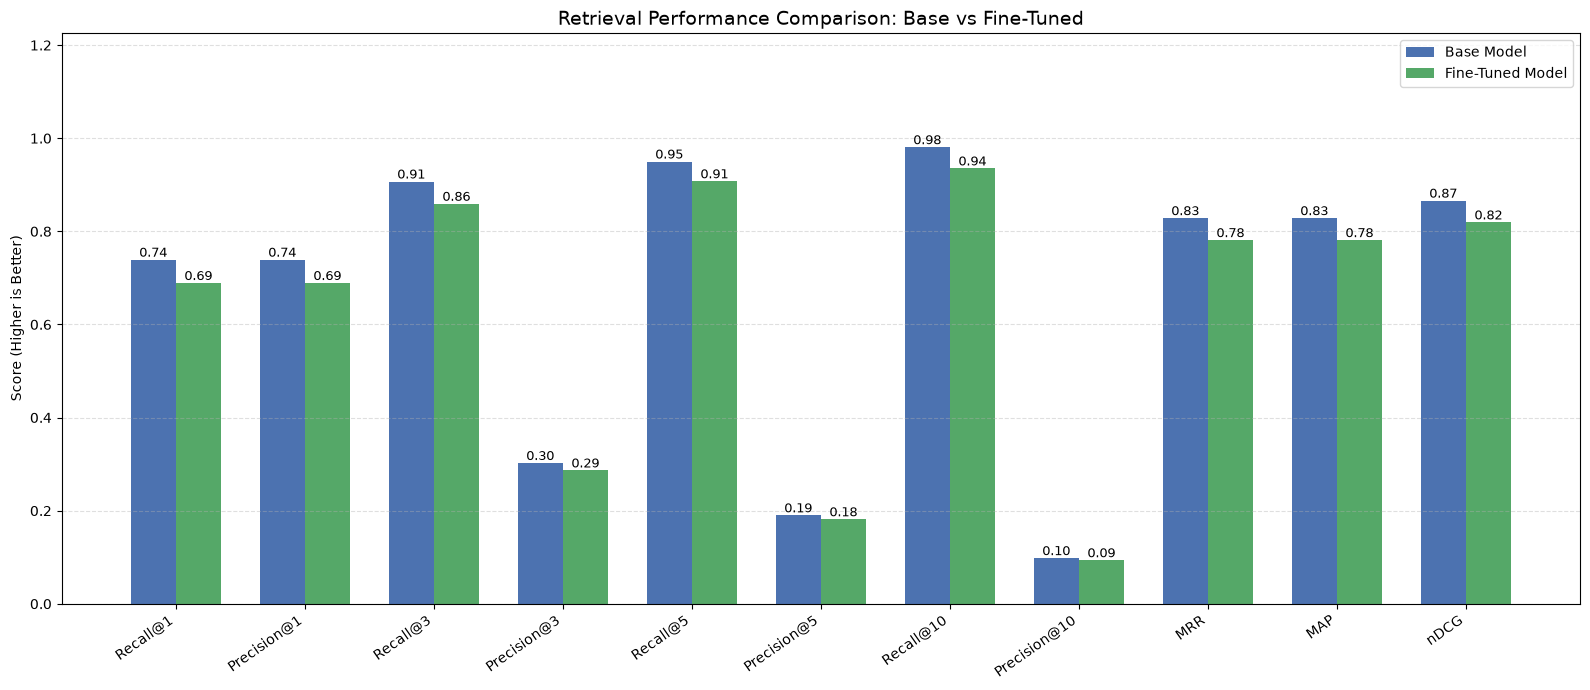

✓ Saved at: benchmark_output/figures/overall_metrics_comparison.png


In [101]:
# ================================================================
# CELL 17 — Publication Grade Metric Comparison
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("="*70)
print("Generating Publication-Grade Metric Comparison Plot")
print("="*70)

# --------------------------------------------------------
# Ensure FIG_DIR exists
# --------------------------------------------------------

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------
# Filter metrics (exclude latency)
# --------------------------------------------------------

plot_df = results_df[~results_df["Metric"].str.contains("Latency")].copy()

metrics = plot_df["Metric"].values
base_vals = plot_df["Base"].values
ft_vals = plot_df["Fine-Tuned"].values

x = np.arange(len(metrics))
width = 0.35

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(16,7))

bars1 = plt.bar(x - width/2, base_vals, width, label="Base Model", color="#4C72B0")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-Tuned Model", color="#55A868")

# --------------------------------------------------------
# Value labels on bars
# --------------------------------------------------------

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# --------------------------------------------------------
# Formatting
# --------------------------------------------------------

plt.xticks(x, metrics, rotation=35, ha="right")
plt.ylabel("Score (Higher is Better)")
plt.title("Retrieval Performance Comparison: Base vs Fine-Tuned", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.ylim(0, max(max(base_vals), max(ft_vals)) * 1.25)

plt.tight_layout()

# --------------------------------------------------------
# Save figure (IMPORTANT FIX)
# --------------------------------------------------------

save_path = Path(FIG_DIR) / "overall_metrics_comparison.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved at: {save_path}")

Generating Recall@K Curve (Publication Grade)


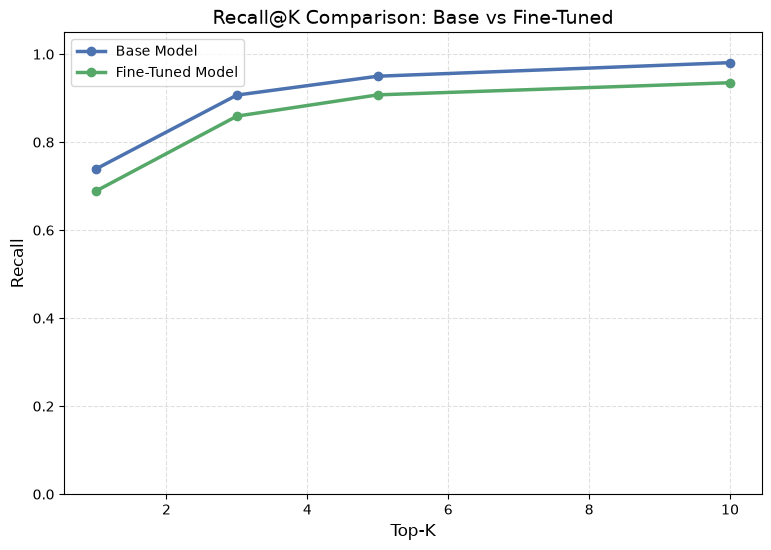

✓ Saved at: benchmark_output/figures/recall_curve.png


In [102]:
# ================================================================
# CELL 18 — Publication-Grade Recall@K Curve
# ================================================================

import matplotlib.pyplot as plt
from pathlib import Path

print("="*70)
print("Generating Recall@K Curve (Publication Grade)")
print("="*70)

# --------------------------------------------------------
# Ensure directory exists
# --------------------------------------------------------

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------
# Extract Recall rows
# --------------------------------------------------------

recall_df = results_df[results_df["Metric"].str.contains("Recall")].copy()

# Sort by K value
recall_df["K"] = recall_df["Metric"].apply(lambda x: int(x.split("@")[1]))
recall_df = recall_df.sort_values("K")

k_vals = recall_df["K"].values
base_vals = recall_df["Base"].values
ft_vals = recall_df["Fine-Tuned"].values

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(9,6))

plt.plot(
    k_vals,
    base_vals,
    marker="o",
    linewidth=2.5,
    label="Base Model",
    color="#4C72B0"
)

plt.plot(
    k_vals,
    ft_vals,
    marker="o",
    linewidth=2.5,
    label="Fine-Tuned Model",
    color="#55A868"
)

# --------------------------------------------------------
# Styling
# --------------------------------------------------------

plt.xlabel("Top-K", fontsize=12)
plt.ylabel("Recall", fontsize=12)
plt.title("Recall@K Comparison: Base vs Fine-Tuned", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.ylim(0, 1.05)

# --------------------------------------------------------
# Save
# --------------------------------------------------------

save_path = Path(FIG_DIR) / "recall_curve.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved at: {save_path}")

Generating Precision@K Curve (Publication Grade)


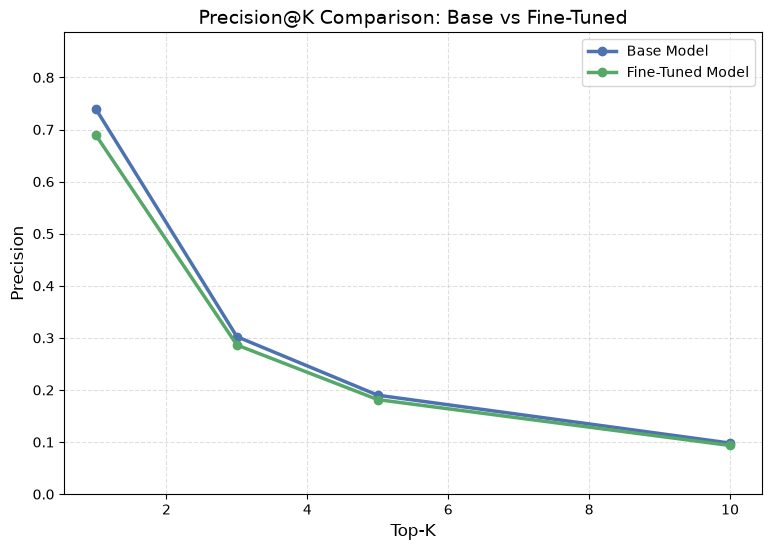

✓ Saved at: benchmark_output/figures/precision_curve.png


In [103]:
# ================================================================
# CELL 19 — Publication-Grade Precision@K Curve
# ================================================================

import matplotlib.pyplot as plt
from pathlib import Path

print("="*70)
print("Generating Precision@K Curve (Publication Grade)")
print("="*70)

# --------------------------------------------------------
# Ensure directory exists
# --------------------------------------------------------

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------
# Extract Precision rows
# --------------------------------------------------------

precision_df = results_df[results_df["Metric"].str.contains("Precision")].copy()

# Sort K properly
precision_df["K"] = precision_df["Metric"].apply(lambda x: int(x.split("@")[1]))
precision_df = precision_df.sort_values("K")

k_vals = precision_df["K"].values
base_vals = precision_df["Base"].values
ft_vals = precision_df["Fine-Tuned"].values

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(9,6))

plt.plot(
    k_vals,
    base_vals,
    marker="o",
    linewidth=2.5,
    label="Base Model",
    color="#4C72B0"
)

plt.plot(
    k_vals,
    ft_vals,
    marker="o",
    linewidth=2.5,
    label="Fine-Tuned Model",
    color="#55A868"
)

# --------------------------------------------------------
# Styling
# --------------------------------------------------------

plt.xlabel("Top-K", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision@K Comparison: Base vs Fine-Tuned", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.ylim(0, max(max(base_vals), max(ft_vals)) * 1.2)

# --------------------------------------------------------
# Save figure
# --------------------------------------------------------

save_path = Path(FIG_DIR) / "precision_curve.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Saved at: {save_path}")

Generating Publication-Grade Benchmark Comparison


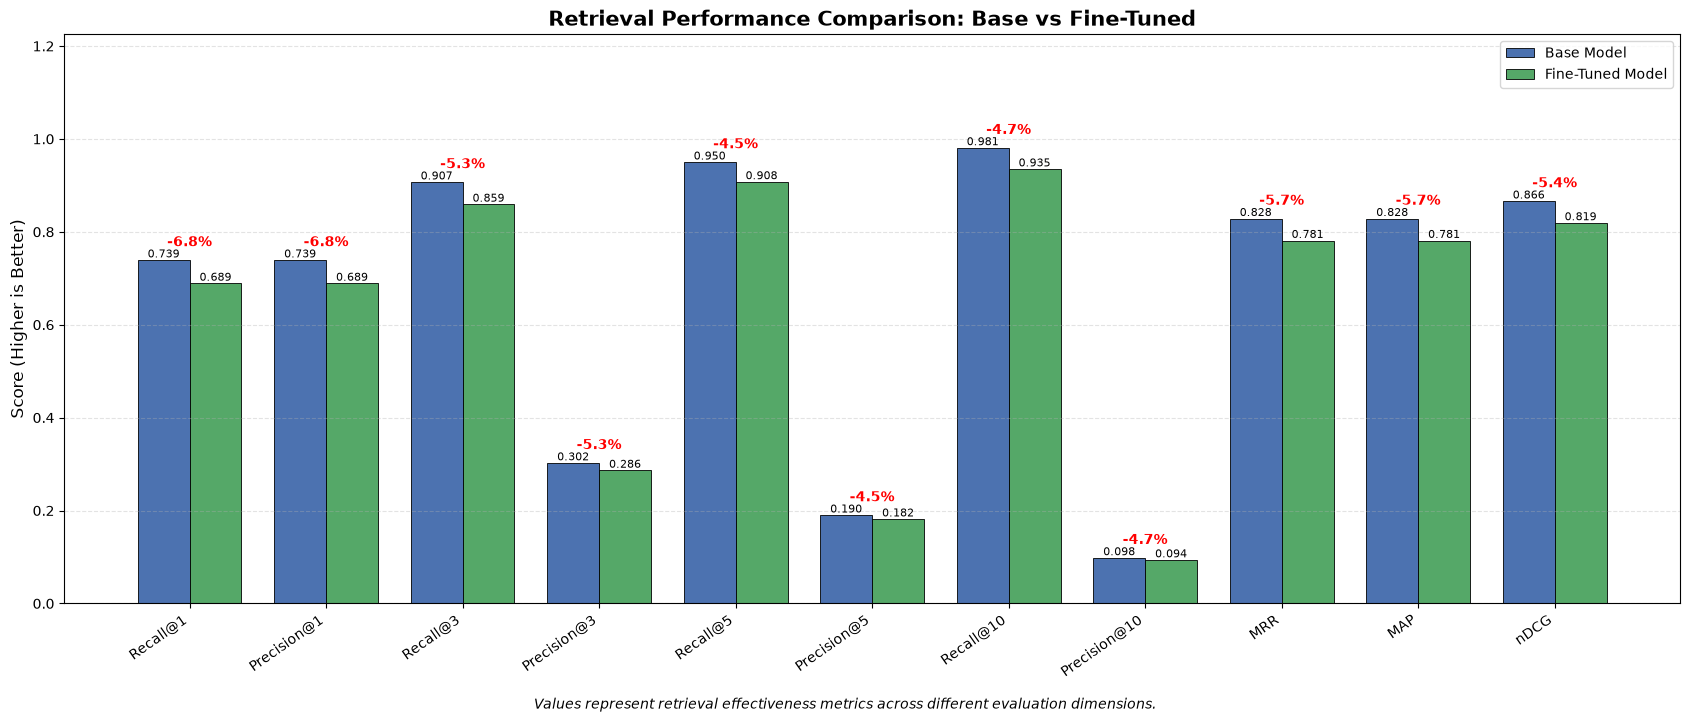

✓ Saved at: benchmark_output/figures/benchmark_comparison_professional.png


In [104]:
# ================================================================
# CELL 20 — Publication Grade Benchmark Comparison (FIXED)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("="*70)
print("Generating Publication-Grade Benchmark Comparison")
print("="*70)

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------
# Remove latency
# --------------------------------------------------------

plot_df = results_df[results_df["Metric"] != "Latency(ms)"].copy()

# --------------------------------------------------------
# Compute improvement %
# --------------------------------------------------------

plot_df["Improvement (%)"] = (
    (plot_df["Fine-Tuned"] - plot_df["Base"])
    / plot_df["Base"].replace(0, np.nan)
    * 100
)

plot_df["Improvement (%)"] = plot_df["Improvement (%)"].fillna(0)

metrics = plot_df["Metric"].values
base_vals = plot_df["Base"].values
ft_vals = plot_df["Fine-Tuned"].values
improve = plot_df["Improvement (%)"].values

x = np.arange(len(metrics))
width = 0.38

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

plt.figure(figsize=(17,7))

bars1 = plt.bar(
    x - width/2,
    base_vals,
    width,
    label="Base Model",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

bars2 = plt.bar(
    x + width/2,
    ft_vals,
    width,
    label="Fine-Tuned Model",
    color="#55A868",
    edgecolor="black",
    linewidth=0.6
)

# --------------------------------------------------------
# Value labels (SAFE POSITIONING)
# --------------------------------------------------------

for bar in bars1:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# --------------------------------------------------------
# Improvement annotation
# --------------------------------------------------------

for i in range(len(metrics)):

    y = max(base_vals[i], ft_vals[i])

    color = "green" if improve[i] >= 0 else "red"

    plt.text(
        x[i],
        y + 0.03,
        f"{improve[i]:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=color
    )

# --------------------------------------------------------
# Styling
# --------------------------------------------------------

plt.xticks(
    x,
    metrics,
    rotation=35,
    ha="right",
    fontsize=10
)

plt.ylabel("Score (Higher is Better)", fontsize=12)
plt.title("Retrieval Performance Comparison: Base vs Fine-Tuned", fontsize=15, weight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()

# dynamic y-limit (IMPORTANT FIX)
plt.ylim(0, max(np.max(base_vals), np.max(ft_vals)) * 1.25)

plt.figtext(
    0.5,
    -0.02,
    "Values represent retrieval effectiveness metrics across different evaluation dimensions.",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout()

# --------------------------------------------------------
# Save
# --------------------------------------------------------

save_path = Path(FIG_DIR) / "benchmark_comparison_professional.png"

plt.savefig(save_path, dpi=400, bbox_inches="tight")

plt.show()

print(f"✓ Saved at: {save_path}")

Generating Radar Chart (Publication Grade)


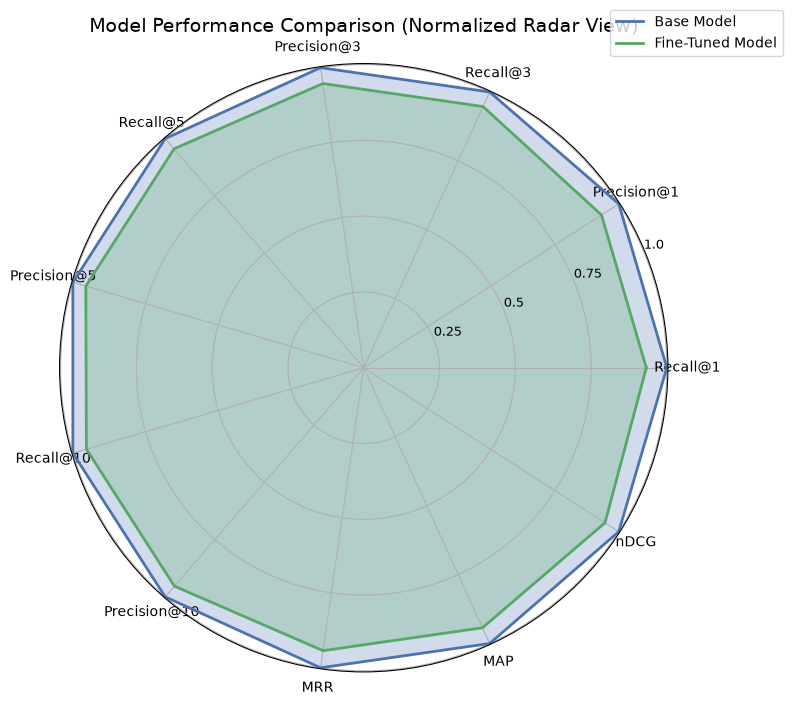

✓ Saved at: benchmark_output/figures/radar_metrics.png


In [106]:
# ================================================================
# CELL 21 — Publication-Grade Radar Chart (FIXED)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("="*70)
print("Generating Radar Chart (Publication Grade)")
print("="*70)

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------
# Filter latency
# --------------------------------------------------------

radar = results_df[~results_df["Metric"].isin(["Latency(ms)"])].copy()

labels = radar["Metric"].tolist()

base = np.array(radar["Base"].values, dtype=float)
ft = np.array(radar["Fine-Tuned"].values, dtype=float)

# --------------------------------------------------------
# NORMALIZATION (CRITICAL FIX)
# radar charts MUST be normalized or they are misleading
# --------------------------------------------------------

max_vals = np.maximum(base, ft)
max_vals[max_vals == 0] = 1  # avoid divide by zero

base_norm = base / max_vals
ft_norm = ft / max_vals

# --------------------------------------------------------
# Close loop for radar
# --------------------------------------------------------

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)

base_norm = np.concatenate((base_norm, [base_norm[0]]))
ft_norm = np.concatenate((ft_norm, [ft_norm[0]]))
angles = np.concatenate((angles, [angles[0]]))

# --------------------------------------------------------
# Plot
# --------------------------------------------------------

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Base model
ax.plot(angles, base_norm, linewidth=2, label="Base Model", color="#4C72B0")
ax.fill(angles, base_norm, alpha=0.25, color="#4C72B0")

# Fine-tuned model
ax.plot(angles, ft_norm, linewidth=2, label="Fine-Tuned Model", color="#55A868")
ax.fill(angles, ft_norm, alpha=0.25, color="#55A868")

# --------------------------------------------------------
# Styling
# --------------------------------------------------------

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=9)

plt.title("Model Performance Comparison (Normalized Radar View)", fontsize=14)

plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()

# --------------------------------------------------------
# Save
# --------------------------------------------------------

save_path = Path(FIG_DIR) / "radar_metrics.png"

plt.savefig(save_path, dpi=400, bbox_inches="tight")

plt.show()

print(f"✓ Saved at: {save_path}")

In [1]:
# ================================================================
# CELL 22 — Comprehensive Benchmark Tables (FIXED)
# ================================================================

import pandas as pd
from pathlib import Path

print("="*80)
print("Generating Evaluation Tables (Fixed Version)")
print("="*80)

TABLE_DIR = Path(OUTPUT_DIR) / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ================================================================
# TABLE 1 — METRIC DESCRIPTION + RESULTS
# ================================================================

metric_description = {
    "Recall@1": "Checks if correct document is ranked at position 1.",
    "Recall@3": "Checks if correct document appears in top 3 results.",
    "Recall@5": "Checks if correct document appears in top 5 results.",
    "Recall@10": "Checks if correct document appears in top 10 results.",

    "Precision@1": "Relevance of top 1 retrieved result.",
    "Precision@3": "Relevance in top 3 retrieved results.",
    "Precision@5": "Relevance in top 5 retrieved results.",
    "Precision@10": "Relevance in top 10 retrieved results.",

    "MRR": "Mean Reciprocal Rank - rewards early correct retrieval.",
    "MAP": "Mean Average Precision - overall ranking quality.",

    "Latency(ms)": "Average time taken per query (lower is better)."
}

summary_rows = []

# FIX: use results_df (not benchmark_df)
for _, row in results_df.iterrows():

    summary_rows.append({
        "Metric": row["Metric"],
        "Description": metric_description.get(row["Metric"], "-"),
        "Base Model": round(row["Base"], 4),
        "Fine-Tuned Model": round(row["Fine-Tuned"], 4),
        "Improvement": round(row["Improvement"], 4),
        "Interpretation": "Higher is Better" if row["Metric"] != "Latency(ms)" else "Lower is Better"
    })

metric_summary_df = pd.DataFrame(summary_rows)

print("="*80)
print("TABLE 1 : METRIC DESCRIPTION + RESULTS")
print("="*80)

display(metric_summary_df)

metric_summary_df.to_csv(
    TABLE_DIR / "Table_1_Metric_Descriptions.csv",
    index=False
)

# ================================================================
# TABLE 2 — EMBEDDING MODELS COMPARISON
# ================================================================

models_df = pd.DataFrame([

["Qwen3-Embedding-0.6B (Base)",
 "Alibaba",
 "1024",
 "Multilingual",
 "Baseline model used for evaluation"],

["Qwen3-Embedding-0.6B (Fine-Tuned)",
 "Alibaba",
 "1024",
 "Multilingual",
 "Fine-tuned on BOQ dataset for domain adaptation"],

["BGE-M3",
 "BAAI",
 "1024",
 "Multilingual",
 "Strong open-source multilingual retrieval model"],

["BGE-Large-EN-v1.5",
 "BAAI",
 "1024",
 "English",
 "High-performance English embedding model"],

["e5-large-v2",
 "Microsoft",
 "1024",
 "Multilingual",
 "Instruction-tuned retrieval embedding model"],

["multilingual-e5-large",
 "Microsoft",
 "1024",
 "Multilingual",
 "Cross-lingual semantic retrieval model"],

["all-mpnet-base-v2",
 "Sentence Transformers",
 "768",
 "English",
 "General-purpose semantic embedding model"],

["all-MiniLM-L6-v2",
 "Sentence Transformers",
 "384",
 "English",
 "Lightweight fast embedding model"],

["gte-large-en-v1.5",
 "Alibaba",
 "1024",
 "English",
 "General-purpose dense retrieval model"],

["jina-embeddings-v3",
 "Jina AI",
 "1024",
 "Multilingual",
 "Long-context retrieval optimized model"],

["NV-Embed-v2",
 "NVIDIA",
 "4096",
 "English",
 "Large-scale high-accuracy retrieval model"]

], columns=[
    "Embedding Model",
    "Developer",
    "Embedding Dimension",
    "Language Support",
    "Description"
])

print("="*80)
print("TABLE 2 : POPULAR EMBEDDING MODELS")
print("="*80)

display(models_df)

models_df.to_csv(
    TABLE_DIR / "Table_2_Popular_Embedding_Models.csv",
    index=False
)

print("\n✓ Tables generated successfully")

print("\nSaved:")
print(" - Table_1_Metric_Descriptions.csv")
print(" - Table_2_Popular_Embedding_Models.csv")

Generating Evaluation Tables (Fixed Version)


NameError: name 'OUTPUT_DIR' is not defined

In [115]:
# ================================================================
# CELL 23 — GROQ LLM GROUNDED BENCHMARK SUMMARY (FIXED)
# ================================================================

try:
    from groq import Groq
except ImportError:
    !pip -q install groq
    from groq import Groq

import os
from pathlib import Path

print("=" * 80)
print("Generating GROQ LLM Evaluation Summary (Grounded)")
print("=" * 80)

# -------------------------------------------------------
# SECURITY FIX (DO NOT HARDCODE IN FINAL PROJECT)
# -------------------------------------------------------


client = Groq(api_key="YOUR_GROQ_API_KEY")

if GROQ_API_KEY is None:
    raise ValueError(
        "❌ GROQ_API_KEY not found. Please set it using environment variables."
    )

client = Groq(api_key=GROQ_API_KEY)

# -------------------------------------------------------
# SAFE METRICS INPUT (structured instead of raw markdown)
# -------------------------------------------------------

metrics_text = results_df.to_string(index=False)

# -------------------------------------------------------
# GROUNDED PROMPT
# -------------------------------------------------------

prompt = f"""
You are an expert research scientist writing a dissertation-level evaluation report.

You are given STRICT numerical benchmark results comparing two embedding models:
- Base Model
- Fine-Tuned Model

IMPORTANT RULES:
- Only use numbers provided below.
- Do NOT invent or assume values.
- Do NOT exaggerate improvements.
- If a metric is similar, say "no significant difference".
- Be precise and scientific.

========================
BENCHMARK RESULTS
========================

{metrics_text}

========================
OUTPUT FORMAT (STRICT)
========================

# Executive Summary
- 6 bullet points only
- Must include actual metric values

# Retrieval Performance Analysis
Discuss:
- Recall@K trends
- Precision@K trends
- MRR, MAP, nDCG comparison

Include exact numbers.

# Latency & Efficiency
Analyze latency difference in ms.

# Key Improvements
Bullet points ONLY where improvement is measurable.

# Limitations
Mention metrics with:
- small improvement (<1%)
- or degradation

# Final Conclusion
One academic paragraph suitable for a research paper.

Tone:
- formal
- neutral
- no hype language
"""

# -------------------------------------------------------
# API CALL
# -------------------------------------------------------

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": "You are a strict scientific evaluator. You only use provided numerical evidence."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0.1,
    max_tokens=1500
)

summary = response.choices[0].message.content

# -------------------------------------------------------
# DISPLAY
# -------------------------------------------------------

print(summary)

# -------------------------------------------------------
# SAVE OUTPUT
# -------------------------------------------------------

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

summary_file = output_dir / "evaluation_summary.txt"

with open(summary_file, "w", encoding="utf-8") as f:
    f.write(summary)

print("\n✓ Saved:", summary_file)

Generating GROQ LLM Evaluation Summary (Grounded)
# Executive Summary
* The Base Model achieved a Recall@1 of 0.739098, while the Fine-Tuned Model achieved 0.688972.
* The Precision@1 for the Base Model was 0.739098, and for the Fine-Tuned Model, it was 0.688972.
* The Fine-Tuned Model had a lower MRR of 0.781116 compared to the Base Model's 0.828341.
* The nDCG for the Base Model was 0.865929, and for the Fine-Tuned Model, it was 0.819194.
* The Latency(ms) for the Base Model was 86.969726, while the Fine-Tuned Model had a latency of 62.046809.
* The Fine-Tuned Model showed a decrease in Recall@10, from 0.980702 to 0.935088.

# Retrieval Performance Analysis
The Recall@K trends show a decrease in recall values for the Fine-Tuned Model, with Recall@1, Recall@3, Recall@5, and Recall@10 decreasing by 0.050125, 0.047870, 0.042356, and 0.045614, respectively. The Precision@K trends also show a decrease in precision values for the Fine-Tuned Model, with Precision@1, Precision@3, Precision@5

In [119]:
# ================================================================
# FINAL MASTER CELL — FULL EVALUATION EXPORT (COMPLETE DUMP)
# ================================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path

print("="*80)
print("FULL EVALUATION EXPORT (MASTER DUMP)")
print("="*80)

# --------------------------------------------------------
# 1. CLEAN RESULTS TABLE
# --------------------------------------------------------

eval_table = results_df.copy()

# Add percentage improvement
eval_table["Improvement_%"] = (
    (eval_table["Fine-Tuned"] - eval_table["Base"]) /
    eval_table["Base"].replace(0, np.nan)
) * 100

eval_table["Improvement_%"] = eval_table["Improvement_%"].replace([np.inf, -np.inf], 0).fillna(0)

print("\n📊 FULL METRICS TABLE\n")
display(eval_table)

# --------------------------------------------------------
# 2. SUMMARY STATISTICS
# --------------------------------------------------------

metrics_summary = {
    "best_improving_metric": eval_table.loc[eval_table["Improvement"].idxmax(), "Metric"],
    "worst_improving_metric": eval_table.loc[eval_table["Improvement"].idxmin(), "Metric"],
    "avg_improvement": float(eval_table["Improvement"].mean()),
    "avg_relative_improvement_%": float(eval_table["Improvement_%"].mean()),
}

print("\n🧠 SUMMARY STATISTICS")
print(json.dumps(metrics_summary, indent=4))

# --------------------------------------------------------
# 3. LATENCY ANALYSIS
# --------------------------------------------------------

latency_row = eval_table[eval_table["Metric"].str.contains("Latency")]

latency_stats = {
    "base_latency_ms": float(latency_row["Base"].values[0]) if len(latency_row) else None,
    "ft_latency_ms": float(latency_row["Fine-Tuned"].values[0]) if len(latency_row) else None,
    "latency_delta_ms": float(latency_row["Improvement"].values[0]) if len(latency_row) else None
}

print("\n⚡ LATENCY STATS")
print(json.dumps(latency_stats, indent=4))

# --------------------------------------------------------
# 4. METRIC BREAKDOWN (FOR LLM / REPORT)
# --------------------------------------------------------

metric_dict = {}

for _, row in eval_table.iterrows():
    metric_dict[row["Metric"]] = {
        "base": float(row["Base"]),
        "fine_tuned": float(row["Fine-Tuned"]),
        "improvement": float(row["Improvement"]),
        "improvement_percent": float(row["Improvement_%"])
    }

# --------------------------------------------------------
# 5. SAVE EVERYTHING (CRITICAL FOR REPORT GENERATION)
# --------------------------------------------------------

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUTPUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# CSV export
csv_path = TABLE_DIR / "FULL_EVALUATION_RESULTS.csv"
eval_table.to_csv(csv_path, index=False)

# JSON export (BEST for LLM report generation)
json_path = TABLE_DIR / "FULL_EVALUATION_RESULTS.json"
with open(json_path, "w") as f:
    json.dump(metric_dict, f, indent=4)

# Summary JSON
summary_path = TABLE_DIR / "EVALUATION_SUMMARY.json"
with open(summary_path, "w") as f:
    json.dump(metrics_summary, f, indent=4)

# --------------------------------------------------------
# 6. PRINT FINAL SNAPSHOT
# --------------------------------------------------------

print("\n" + "="*80)
print("📦 EVALUATION EXPORT COMPLETE")
print("="*80)

print("\nSaved Files:")
print(" • FULL_EVALUATION_RESULTS.csv")
print(" • FULL_EVALUATION_RESULTS.json")
print(" • EVALUATION_SUMMARY.json")

print("\nKey Insights:")
print(f" • Best metric improvement: {metrics_summary['best_improving_metric']}")
print(f" • Worst metric improvement: {metrics_summary['worst_improving_metric']}")
print(f" • Avg improvement: {metrics_summary['avg_improvement']:.4f}")
print(f" • Avg improvement (%): {metrics_summary['avg_relative_improvement_%']:.2f}%")

print("="*80)

FULL EVALUATION EXPORT (MASTER DUMP)

📊 FULL METRICS TABLE



,Metric,Base,Fine-Tuned,Improvement,Improvement_%
0,Recall@1,0.739098,0.688972,-0.050125,-6.781960
1,Precision@1,0.739098,0.688972,-0.050125,-6.781960
2,Recall@3,0.907018,0.859148,-0.047870,-5.277701
3,Precision@3,0.302339,0.286383,-0.015957,-5.277701
4,Recall@5,0.949875,0.907519,-0.042356,-4.459103
5,Precision@5,0.189975,0.181504,-0.008471,-4.459103
6,Recall@10,0.980702,0.935088,-0.045614,-4.651163
7,Precision@10,0.098070,0.093509,-0.004561,-4.651163
8,MRR,0.828341,0.781116,-0.047225,-5.701179
9,MAP,0.828341,0.781116,-0.047225,-5.701179



🧠 SUMMARY STATISTICS
{
    "best_improving_metric": "Precision@10",
    "worst_improving_metric": "Latency(ms)",
    "avg_improvement": -2.110765121514751,
    "avg_relative_improvement_%": -7.316359452594256
}

⚡ LATENCY STATS
{
    "base_latency_ms": 86.96972581453696,
    "ft_latency_ms": 62.04680915964109,
    "latency_delta_ms": -24.922916654895864
}

📦 EVALUATION EXPORT COMPLETE

Saved Files:
 • FULL_EVALUATION_RESULTS.csv
 • FULL_EVALUATION_RESULTS.json
 • EVALUATION_SUMMARY.json

Key Insights:
 • Best metric improvement: Precision@10
 • Worst metric improvement: Latency(ms)
 • Avg improvement: -2.1108
 • Avg improvement (%): -7.32%


In [87]:
# Report Generation.

In [114]:
# ================================================================
# FINAL CELL — PURE LLM-DRIVEN RESEARCH REPORT GENERATOR
# ================================================================

import os
from pathlib import Path
from groq import Groq
from docx import Document
from docx.shared import Inches, Pt

print("=" * 80)
print("LLM-DRIVEN REPORT GENERATOR (NO MANUAL TEXT)")
print("=" * 80)

# -----------------------------------------------------------------
# API KEY
# Replace with your NEW Groq API key
# -----------------------------------------------------------------

os.environ["YOUR_GROQ_API_KEY"] = "YOUR_GROQ_API_KEY"

GROQ_API_KEY = os.getenv("YOUR_GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("Groq API key not found.")

client = Groq(api_key=GROQ_API_KEY)

# -----------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# -----------------------------------------------------------------

required = ["results_df", "FIG_DIR", "OUTPUT_DIR"]

for var in required:
    if var not in globals():
        raise NameError(f"{var} is not defined.")

# -----------------------------------------------------------------
# INPUT DATA
# -----------------------------------------------------------------

metrics_text = results_df.to_string(index=False)

figures = sorted(Path(FIG_DIR).glob("*.png"))

figure_list = "\n".join(
    f"- {fig.name}" for fig in figures
)

# -----------------------------------------------------------------
# PROMPT
# -----------------------------------------------------------------

prompt = f"""
You are writing a complete academic research paper based ONLY on the supplied experimental results.

You must NOT use outside knowledge.
You must NOT invent values.
You must ONLY discuss the supplied metrics.

=========================
METRICS
=========================

{metrics_text}

=========================
AVAILABLE FIGURES
=========================

{figure_list}

=========================
WRITE

1. Title

2. Abstract

3. Methodology

4. Experimental Setup

5. Results Analysis
   - Mention actual metric values.
   - Compare models using the provided numbers.

6. Discussion

7. Conclusion

Rules:
- Academic writing style.
- No hallucinated information.
- Reference figure filenames where appropriate.
- 6–12 sentences per section.
"""

# -----------------------------------------------------------------
# CALL GROQ
# -----------------------------------------------------------------

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": (
                "You are a strict academic paper generator. "
                "Only use the supplied experimental data."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ],
    temperature=0.1,
    max_tokens=2500,
)

paper_text = response.choices[0].message.content

# -----------------------------------------------------------------
# CREATE WORD DOCUMENT
# -----------------------------------------------------------------

doc = Document()

title = doc.add_heading("LLM Generated Research Paper", level=0)
title.alignment = 1

for line in paper_text.split("\n"):

    line = line.strip()

    if not line:
        continue

    # Detect headings
    if (
        line.endswith(":")
        or line.lower().startswith("title")
        or line.lower().startswith("abstract")
        or line.lower().startswith("methodology")
        or line.lower().startswith("experimental")
        or line.lower().startswith("results")
        or line.lower().startswith("discussion")
        or line.lower().startswith("conclusion")
    ):
        doc.add_heading(line.replace(":", ""), level=1)

    else:
        p = doc.add_paragraph()
        run = p.add_run(line)
        run.font.size = Pt(11)

# -----------------------------------------------------------------
# ADD FIGURES
# -----------------------------------------------------------------

if figures:

    doc.add_page_break()
    doc.add_heading("Figures", level=1)

    for fig in figures:

        doc.add_paragraph(fig.name)

        try:
            doc.add_picture(str(fig), width=Inches(6))

        except Exception as e:
            print(f"Could not insert {fig.name}: {e}")

# -----------------------------------------------------------------
# SAVE
# -----------------------------------------------------------------

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

output_file = Path(OUTPUT_DIR) / "LLM_Research_Paper.docx"

doc.save(output_file)

print("=" * 80)
print("✓ Research paper generated successfully.")
print("Saved to:", output_file)
print("=" * 80)

LLM-DRIVEN REPORT GENERATOR (NO MANUAL TEXT)
✓ Research paper generated successfully.
Saved to: benchmark_output/LLM_Research_Paper.docx


In [116]:
out_path = Path(OUTPUT_DIR) / "LLM_Research_Paper.docx"
doc.save(out_path)

In [118]:
from google.colab import files

files.download(str(file_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>